# An Introduction to Natural Language Processing using NLTK

Import NLTK and download required resources.

In [27]:
!pip install -qq svgling
import nltk

nltk.download("book", quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True)


True

## Misc

### Stop Words

<details>
<summary>Click to expand informal defintion</summary>

Stop words are very common words (like "the", "and", "is") that are often removed in text processing because they carry little semantic meaning.

</details>

In [28]:
stop_words = set(nltk.corpus.stopwords.words('english'))
print(stop_words)

{'its', "don't", 'after', 'herself', 'shouldn', 'then', 'nor', "he's", 'now', 'into', 'so', 'once', 'll', 'who', "i'd", 'only', 'themselves', 'of', 'up', 'above', 'both', 'm', 'such', 't', 'are', 'but', "he'd", "i'll", 'shan', 'the', 'why', 'can', 'itself', 'wasn', 'should', 'couldn', 'was', "should've", 'had', 'it', 've', 'before', "they've", 'or', "it'll", 'theirs', 'over', 'below', "we'd", 'our', "they're", 'his', 'here', "you'll", 'any', "hadn't", 'he', 'mightn', 'these', "we've", 'on', 'further', 'just', 'about', 'them', 'my', 'd', 'against', 'we', 'under', "hasn't", 'when', "you've", 'whom', "aren't", 'being', 'more', 'yourselves', 'ain', 'those', 'own', 'needn', 'haven', 'do', 'no', 're', 'yours', 'most', 'again', 'weren', 'than', 'doing', "doesn't", "couldn't", 'this', 'be', "shan't", 'did', 'very', 'through', "i've", 'her', 'myself', 'few', 'ourselves', 'not', "we're", "they'd", 'they', "we'll", 'your', 'for', 'as', "i'm", 'some', 'hasn', 'in', 'i', 'between', 'their', "you're

### Lemmatization

<details>
<summary>Click to expand informal defintion</summary>

Lemmatization maps words to their dictionary (base) form using dictionary.

</details>

In [29]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

print("went :", lemmatizer.lemmatize("went", wordnet.VERB))
print("better (adjective):", lemmatizer.lemmatize("better", wordnet.ADJ))
print("better (adverb):", lemmatizer.lemmatize("better", wordnet.ADV))
print("corpora :", lemmatizer.lemmatize("corpora"))

def lemmatize_text(text: str):
  def to_wordnet_pos(nltk_tag):
    if nltk_tag.startswith('J'):
      return wordnet.ADJ
    elif nltk_tag.startswith('V'):
      return wordnet.VERB
    elif nltk_tag.startswith('N'):
      return wordnet.NOUN
    elif nltk_tag.startswith('R'):
      return wordnet.ADV
    else:
      return wordnet.NOUN # Default value to avoid errors
  words = nltk.word_tokenize(text)
  tags = nltk.pos_tag(words)
  for word, pos in tags:
    yield lemmatizer.lemmatize(word, pos=to_wordnet_pos(pos))

print(" ".join(lemmatize_text("He sings better than before.")))
print(" ".join(lemmatize_text("They better leave now.")))

went : go
better (adjective): good
better (adverb): well
corpora : corpus
He sing good than before .
They better leave now .


## Tokenization, POS, Entities
Take a sentence and tokenize into words. Then apply a part-of-speech tagger.

<details>
<summary>Click to expand informal definition of tokenization</summary>

Tokenization is the process of splitting text into smaller units (tokens), such as words or sentences.

</details>

<details>
<summary>Click to expand informal definition of part-of-speech tagging</summary>

POS tagging (part-of-speech tagging) assigns grammatical categories (like noun, verb, adjective) to each token in a text.

</details>

['At', 'eight', "o'clock", 'on', 'Thursday', 'morning', 'Arthur', 'Mills', 'did', "n't", 'feel', 'very', 'good', '.']


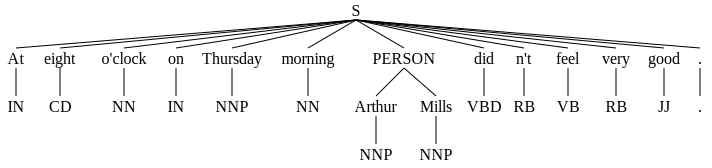

In [30]:
sentence = """At eight o'clock on Thursday morning Arthur Mills didn't feel very good."""

tokens = nltk.word_tokenize(sentence)

print(tokens)

tagged = nltk.pos_tag(tokens)

# Display it in a nice tree
nltk.chunk.ne_chunk(tagged)


You can find long forms of POS tags [online](https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html).

# Named Entity Recognition

<details>
<summary>Click to expand informal definition of Named Entity Recognition</summary>

Named Entity Recognition (NER) identifies and labels real-world entities in text (such as people, organizations, locations, or dates).

</details>

In [31]:
import spacy
from spacy import displacy
from IPython.display import display, HTML

nlp = spacy.load("en_core_web_sm")
doc = nlp("Barack Obama was born in Hawaii. He was elected president in 2008.")

displacy.render(doc, style="ent", jupyter=True)

You can find long forms of NER categories [online](https://www.arcgis.com/home/item.html?id=97369a6f1200428ba060410d13dbb078).

## Concordance

<details>
<summary>Click to expand informal definition of concordance</summary>

A concordance is a list of occurrences of a word (or pattern) shown together with their surrounding context in a text corpus.
</details>

In [32]:
%matplotlib inline

from nltk.book import *

Generate a key-word in context concordance

In [33]:
text1.concordance("monstrous")

Displaying 11 of 11 matches:
ong the former , one was of a most monstrous size . ... This came towards us , 
ON OF THE PSALMS . " Touching that monstrous bulk of the whale or ork we have r
ll over with a heathenish array of monstrous clubs and spears . Some were thick
d as you gazed , and wondered what monstrous cannibal and savage could ever hav
that has survived the flood ; most monstrous and most mountainous ! That Himmal
they might scout at Moby Dick as a monstrous fable , or still worse and more de
th of Radney .'" CHAPTER 55 Of the Monstrous Pictures of Whales . I shall ere l
ing Scenes . In connexion with the monstrous pictures of whales , I am strongly
ere to enter upon those still more monstrous stories of them which are to be fo
ght have been rummaged out of this monstrous cabinet there is no telling . But 
of Whale - Bones ; for Whales of a monstrous size are oftentimes cast up dead u


Find words with similar concordance to a given word

In [34]:
print(text1) # info about the text (name, author, year)
text1.similar("monstrous") # words that appear in similar contexts (based on surrounding words)
print()
print(text2)
text2.similar("monstrous")


<Text: Moby Dick by Herman Melville 1851>
true contemptible christian abundant few part mean careful puzzled
mystifying passing curious loving wise doleful gamesome singular
delightfully perilous fearless

<Text: Sense and Sensibility by Jane Austen 1811>
very so exceedingly heartily a as good great extremely remarkably
sweet vast amazingly


Find contexts that both words share, i.e., where "monstrous" and "very" occur in the same position relative to neighboring words (i.e., leftWord _ rightWord), highlighting overlapping usage patterns.
- For example, am_glad: both words occur in contexts like "am very glad" and "am monstrous glad".

NLTK is showing that “monstrous” and “very” are used in similar grammatical positions (as intensifiers before adjectives), even if some combinations (like "monstrous glad") may sound archaic or stylistic.

In [35]:
text2.common_contexts(["monstrous", "very"])

am_glad a_pretty a_lucky is_pretty be_glad


Plot where in the text certain words appear across the text, helping you see how their usage is distributed (e.g., clustered in certain sections or spread throughout).

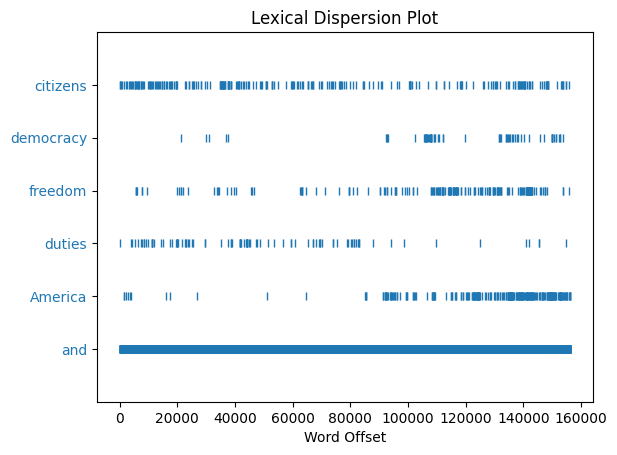

In [36]:
text4.dispersion_plot(["citizens", "democracy", "freedom", "duties", "America", "and"])

Print the identity of a text, the length of the text and its vocabulary

In [37]:
print(text3)
print(len(text3))
print(sorted(set(text3)))

<Text: The Book of Genesis>
44764
['!', "'", '(', ')', ',', ',)', '.', '.)', ':', ';', ';)', '?', '?)', 'A', 'Abel', 'Abelmizraim', 'Abidah', 'Abide', 'Abimael', 'Abimelech', 'Abr', 'Abrah', 'Abraham', 'Abram', 'Accad', 'Achbor', 'Adah', 'Adam', 'Adbeel', 'Admah', 'Adullamite', 'After', 'Aholibamah', 'Ahuzzath', 'Ajah', 'Akan', 'All', 'Allonbachuth', 'Almighty', 'Almodad', 'Also', 'Alvah', 'Alvan', 'Am', 'Amal', 'Amalek', 'Amalekites', 'Ammon', 'Amorite', 'Amorites', 'Amraphel', 'An', 'Anah', 'Anamim', 'And', 'Aner', 'Angel', 'Appoint', 'Aram', 'Aran', 'Ararat', 'Arbah', 'Ard', 'Are', 'Areli', 'Arioch', 'Arise', 'Arkite', 'Arodi', 'Arphaxad', 'Art', 'Arvadite', 'As', 'Asenath', 'Ashbel', 'Asher', 'Ashkenaz', 'Ashteroth', 'Ask', 'Asshur', 'Asshurim', 'Assyr', 'Assyria', 'At', 'Atad', 'Avith', 'Baalhanan', 'Babel', 'Bashemath', 'Be', 'Because', 'Becher', 'Bedad', 'Beeri', 'Beerlahairoi', 'Beersheba', 'Behold', 'Bela', 'Belah', 'Benam', 'Benjamin', 'Beno', 'Beor', 'Bera', 'Bered', 'Beriah

Print some statistics of word occurrence in the text

In [38]:
def lexical_diversity(text):
  return len(set(text)) / len(text)
def percentage(count, total):
  return 100 * count / total

print(lexical_diversity(text3))
print(lexical_diversity(text5))
print(percentage(text4.count('a'), len(text4)))


0.06230453042623537
0.13477005109975562
1.4569256756756757


# NLTK in Action

In the following, we will create a classifier that should tell us whether a movie review is positive or bad ("sentiment analysis").

## Preparing the Dataset

To do so, we will be using the IMDB movie review corpus, which we can fetch through `nltk.corpus.movie_reviews.`:

Classes represented in the movie reviews: ['neg', 'pos']
#Documents: 2000
#Documents that are neg: 1000
#Documents that are pos: 1000
Average number of words per review: 791.91
Average number of words per positive review: 832.564
Average number of words per negative review: 751.256


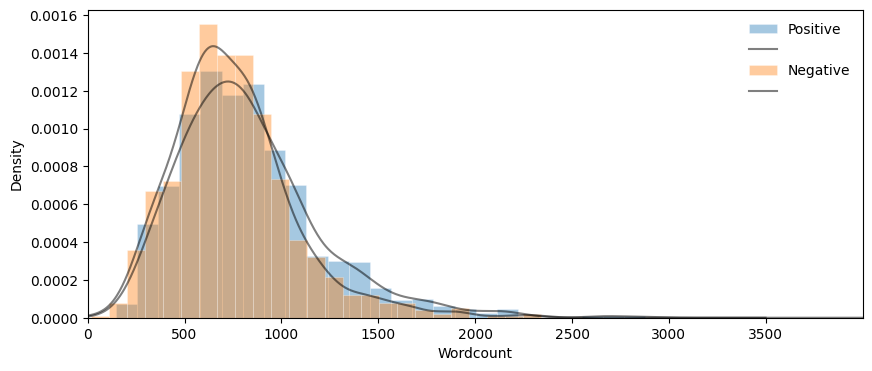

The most common words are: , the . a and of to ' is in ...
(array([1., 1., 1., ..., 0., 0., 0.], shape=(2000,), dtype=float32), 'neg')


In [39]:
import nltk
from nltk.corpus import movie_reviews
import random
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nltk.download('movie_reviews', quiet=True)

print(f"Classes represented in the movie reviews: {movie_reviews.categories()}")
print(f"#Documents: {sum(len(movie_reviews.fileids(cat)) for cat in movie_reviews.categories())}")
for cat in movie_reviews.categories():
  print(f"#Documents that are {cat}: {len(movie_reviews.fileids(cat))}")

# Write the dataset into a list[tuple[list[str], str]], where the first element
# of the tuple is the document's text and the second element is its label (pos
# or neg)
documents = [(movie_reviews.words(fileid), category)
             for category in movie_reviews.categories()
             for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)

print(f"Average number of words per review: {(sum(len(w) for w,_ in documents))/len(documents)}")
print(f"Average number of words per positive review: {(sum(len(w) for w,c in documents if c=='pos'))/len(movie_reviews.fileids('pos'))}")
print(f"Average number of words per negative review: {(sum(len(w) for w,c in documents if c=='neg'))/len(movie_reviews.fileids('neg'))}")
## Draw histograms
def render(dist: list, label: str, ax):
  df = pd.DataFrame(dist)
  df.plot.hist(bins=25, density=True, edgecolor='w', linewidth=0.5, ax=ax, alpha=0.4)
  df.plot.density(color='k', alpha=0.5, ax=ax)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 4))
ax.set_xlim((0, 4000))
render((len(w) for w,c in documents if c=='pos'), "positive", ax)
render((len(w) for w,c in documents if c=='neg'), "negative", ax)
plt.ylabel("Density")
plt.xticks(np.arange(0, 4000, step=500))
plt.xlabel("Wordcount")
ax.legend(labels=['Positive', '', 'Negative', ''], frameon=False)
plt.savefig('score-density.pdf')
plt.show()
###


# Features
# There are many ways how we could represent the text. For now, we will choose
# to represent it using a BOW model of the 2000 most common words in the dataset
stop_words = set(nltk.corpus.stopwords.words('english'))

def normalize_words(words):
  for w in words:
    yield w.lower()

all_words = nltk.FreqDist(normalize_words(movie_reviews.words()))
common_words, _ = zip(*all_words.most_common(2000))
print(f"The most common words are: {' '.join(common_words[:10])} ...")

# Now that we have the most common words, we represent a document as a 2000
# dimensional boolean vector.
def doc_features(document: list[str]) -> dict[str, bool]:
    docwords = set(document)
    return np.fromiter(((word in docwords) for word in common_words), dtype=np.float32)

dataset = [(doc_features(d), c) for (d, c) in documents]
print(dataset[0])

# Finally, we can split our dataset into training and testing splits
train_set, test_set = train_test_split(dataset, test_size=0.25, random_state=42)

X_train, y_train = zip(*train_set)
X_test, y_test = zip(*test_set)

## Training Logistic Regression

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Train logistic regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.846
              precision    recall  f1-score   support

         neg       0.82      0.87      0.84       239
         pos       0.87      0.83      0.85       261

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



films adapted from comic books have had plenty of success , whether they ' re about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there ' s never really been a comic book like from hell before . for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid ' 80s with a 12 - part series called the watchmen . to say moore and campbell thoroughly researched the subject of jack the ripper would be like saying michael jackson is starting to look a little odd . the book ( or " graphic novel , " if you will ) is over 500 pages long and includes nearly 30 more that consist of nothing but footnotes . in other words , don ' t dismiss this film because of its source . if you can get past the whole comic book thing , you might find another stumbling block in from hell ' s directors , albert and allen hughes . getting the hughes brothers to direct this seems almos

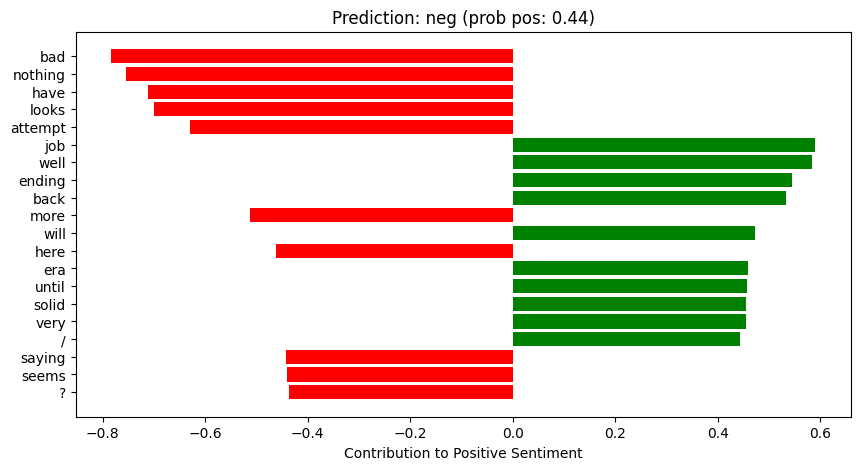

In [41]:
coefs = clf.coef_[0]  # for binary classification

def visualize_word_contributions(text_words):
    # Create features for the input
    X = doc_features(text_words).reshape(1, -1)

    # Get prediction
    prob = clf.predict_proba(X)[0]
    pred = clf.predict(X)[0]

    # Show contributions
    contributions = [(word, coefs[i]) for i, word in enumerate(common_words) if word in text_words]

    # Sort by magnitude
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    contributions = contributions[:20]

    # Plot
    words, weights = zip(*contributions)
    colors = ['green' if w > 0 else 'red' for w in weights]

    plt.figure(figsize=(10, 5))
    plt.barh(words, weights, color=colors)
    plt.xlabel("Contribution to Positive Sentiment")
    plt.title(f"Prediction: {pred} (prob pos: {prob[1]:.2f})")
    plt.gca().invert_yaxis()
    plt.show()

# Example usage
example_text = list(movie_reviews.words(movie_reviews.fileids('pos')[0]))
print(" ".join(example_text))
visualize_word_contributions(example_text)


['the', 'movie', 'is', 'bad']
[0. 1. 0. ... 0. 0. 0.]


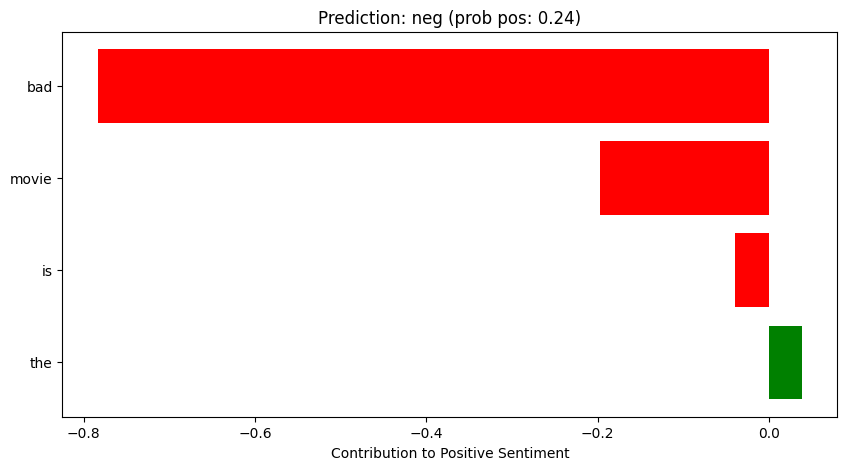

In [42]:
example_text = list(normalize_words(nltk.word_tokenize("The movie is bad")))
print(example_text)
print(doc_features(example_text))
visualize_word_contributions(example_text)

['the', 'movie', 'is', 'good']
[0. 1. 0. ... 0. 0. 0.]


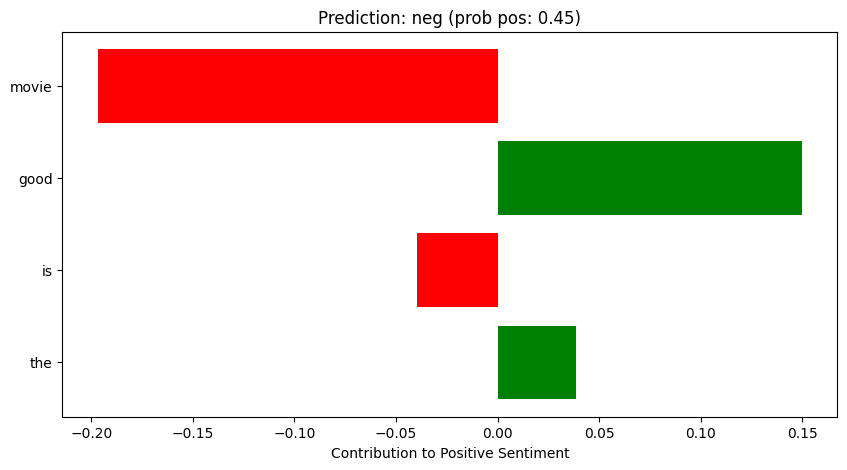

In [43]:
example_text = list(normalize_words(nltk.word_tokenize("The movie is good")))
print(example_text)
print(doc_features(example_text))
visualize_word_contributions(example_text)

['the', 'movie', 'could', 'not', 'have', 'been', 'better']
[0. 1. 0. ... 0. 0. 0.]


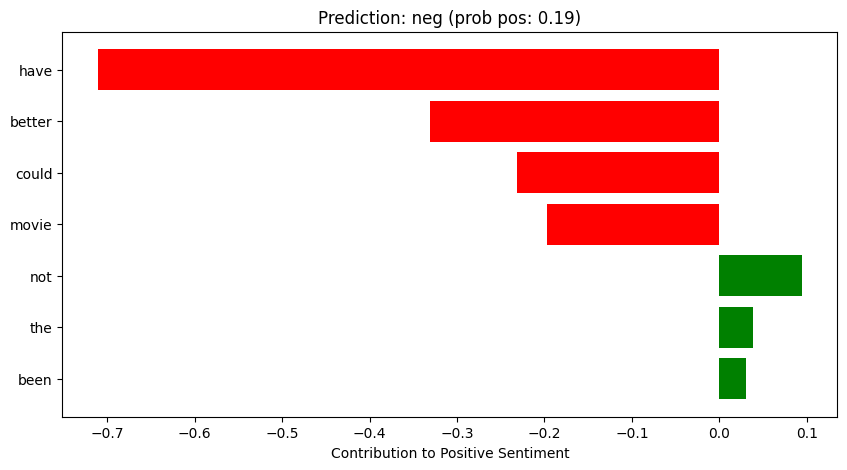

In [44]:
example_text = list(normalize_words(nltk.word_tokenize("The movie could not have been better")))
print(example_text)
print(doc_features(example_text))
visualize_word_contributions(example_text)

**Questions**
- How could the effectiveness be improved further?


**See Also:**
- [Sentiment Flow – A General Model of Web Review Argumentation](https://downloads.webis.de/publications/papers/wachsmuth_2015a.pdf); Wachsmuth et al. 2015